In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from systematic_plots import load_homepath


evaluation_path = load_homepath() + "../evaluation/cistrans/"
df = pd.read_csv(evaluation_path+"summary2.csv") 
df["sigma_test_uncertainty"]

0     0.100000
1     0.122474
2     0.158114
3     0.100000
4     0.000000
5     0.100000
6     0.100000
7     0.122474
8     0.122474
9     0.000000
10    0.158114
11    0.000000
12    0.000000
13    0.000000
14    0.200000
15    0.000000
16    0.122474
17    0.000000
18    0.000000
19    0.000000
20    0.122474
21    0.000000
22    0.000000
23    0.000000
Name: sigma_test_uncertainty, dtype: float64

In [71]:
df 

,Unnamed: 0,f_noise,phi_noise,alpha,offset,true_phases,percentile,sigma,sigma_test_best_guess,sigma_test_uncertainty,many_negsum_best_guess_best_guess,many_negsum_best_guess_uncertainty,single_negsum_overview_best_guess,single_negsum_model_best_guess,single_negsum_model_uncertainty
0,0,0.0,0.0,0.2,True,True,0.10,8.500365,5.95,0.100000,6.406315,2.314211e-02,6.401487,6.208063,0.048348
1,1,0.0,0.0,0.2,True,True,0.01,32.185768,5.60,0.122474,5.559379,2.917805e-06,5.559381,5.559375,0.006103
2,2,0.0,0.0,0.2,False,True,0.10,8.500365,4.00,0.158114,4.245578,3.278651e-03,4.246266,4.138344,0.084722
3,3,0.0,0.0,0.2,False,True,0.01,32.185769,4.45,0.100000,4.421735,3.684819e-03,4.422805,4.422433,0.014070
4,4,0.0,0.0,0.2,True,False,0.10,6.594419,5.00,0.000000,5.581704,3.025685e-02,5.575999,5.391843,0.048469
5,5,0.0,0.0,0.2,True,False,0.01,24.244960,4.95,0.100000,4.998352,2.366279e-06,4.998350,4.984266,0.012251
6,6,0.0,0.0,0.2,False,False,0.10,6.594419,3.45,0.100000,3.745510,4.647534e-03,3.745209,3.615559,0.108169
7,7,0.0,0.0,0.2,False,False,0.01,24.244957,3.90,0.122474,3.959381,1.201547e-03,3.959995,3.959167,0.021180
8,8,0.0,0.0,0.5,True,True,0.10,8.500362,2.60,0.122474,2.631258,7.634491e-03,2.629646,2.581693,0.033375
9,9,0.0,0.0,0.5,True,True,0.01,32.185777,2.25,0.000000,2.225690,9.431969e-07,2.225691,2.220663,0.013796


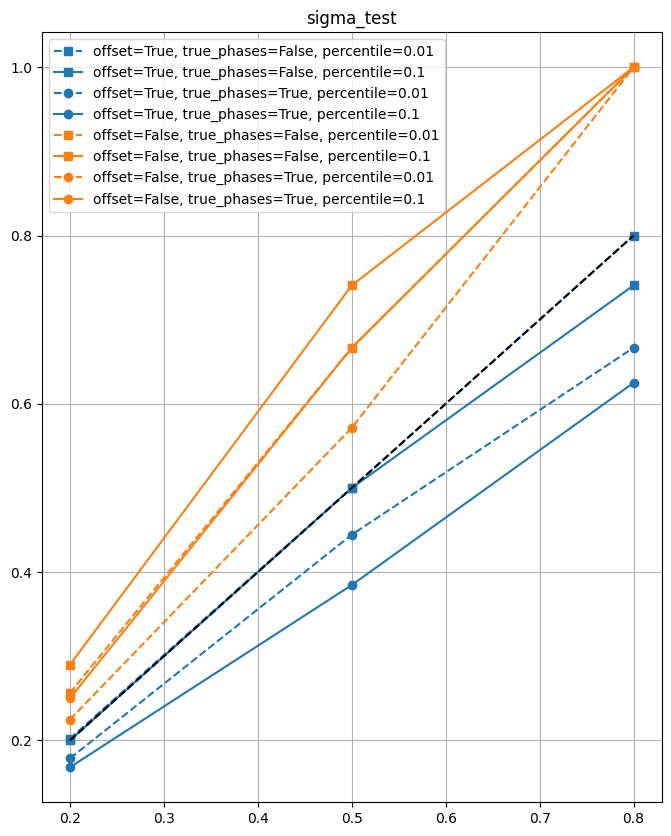

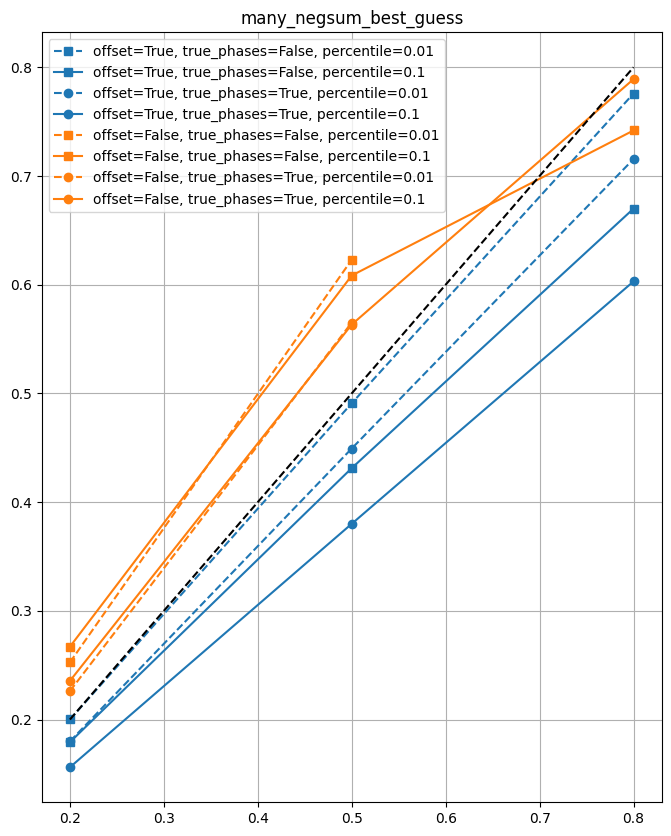

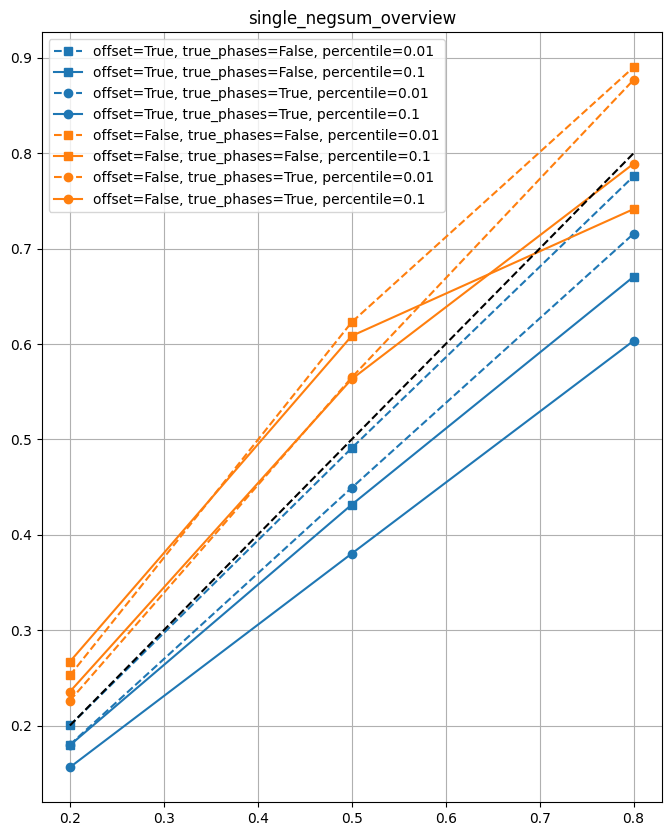

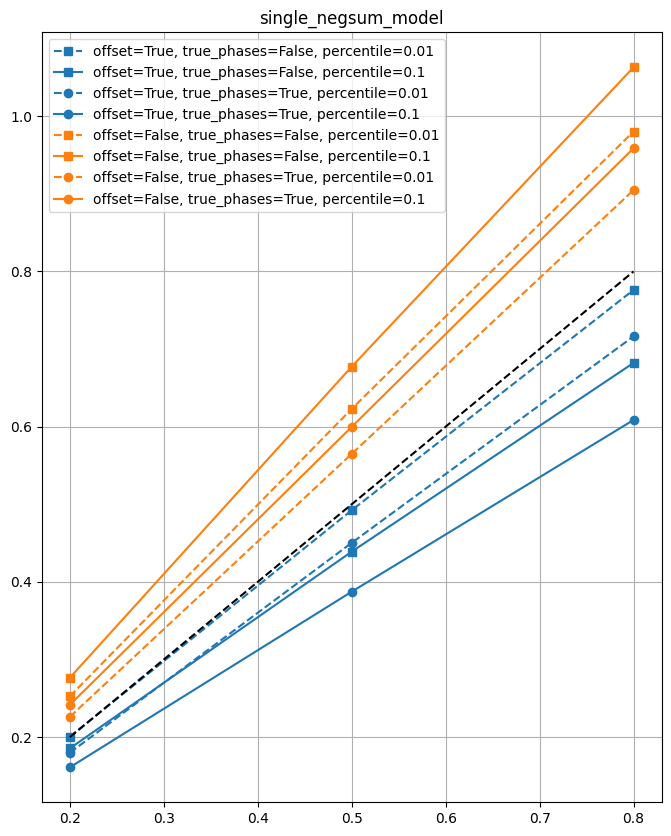

In [72]:
import itertools

value_cols = [
    "sigma_test",
    "many_negsum_best_guess",
    "single_negsum_overview",
    "single_negsum_model",
]

conds = {
    # "alpha": 0.2,
    "phi_noise": 0,
    # "percentile": 0.01,
}

vary_conds = [
    "offset", "true_phases", "percentile"
]


for col in value_cols:
    plt.figure(figsize=(8,10))
    subset = df.copy()
    plt.title(col)
    for key, val in conds.items():
        subset = subset[subset[key] == val]
    # Ensure both True and False for 'offset' are present
    if "offset" in vary_conds:
        all_offsets = [True, False]
        subset = subset[subset["offset"].isin(all_offsets)]
    # Get all unique values for each vary_cond in the subset
    vary_cond_values = []
    for vary_cond in vary_conds:
        if vary_cond == "offset":
            vary_cond_values.append([True, False])
        else:
            vary_cond_values.append(sorted(subset[vary_cond].unique()))
    # Create cartesian product of all combinations
    for combo in itertools.product(*vary_cond_values):
        mask = np.ones(len(subset), dtype=bool)
        label_parts = []
        for i, vary_cond in enumerate(vary_conds):
            mask &= (subset[vary_cond] == combo[i])
            label_parts.append(f"{vary_cond}={combo[i]}")
        subsub = subset[mask]
        if not subsub.empty:
            # Assign colors, markers, and linestyles based on vary_conds
            color_map = {True: 'tab:blue', False: 'tab:orange'}
            marker_map = {True: 'o', False: 's'}
            linestyle_map = {0.1: '-', 0.01: '--'}

            color = color_map[combo[0]]  # offset
            marker = marker_map[combo[1]]  # true_phases
            linestyle = linestyle_map.get(combo[2], '-')  # percentile

            plt.plot(
                subsub["alpha"],
                1/subsub[f"{col}_best_guess"],
                marker=marker,
                color=color,
                linestyle=linestyle,
                label=f"{', '.join(label_parts)}"
            )
    plt.legend()
    plt.grid()
    
    plt.plot(subset["alpha"], subset["alpha"], 'k--', label="y=x")


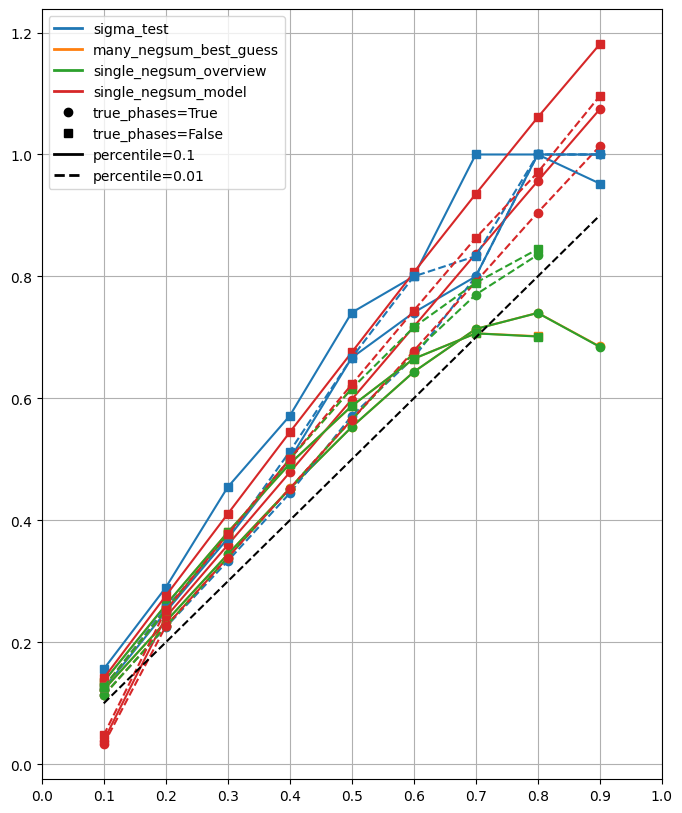

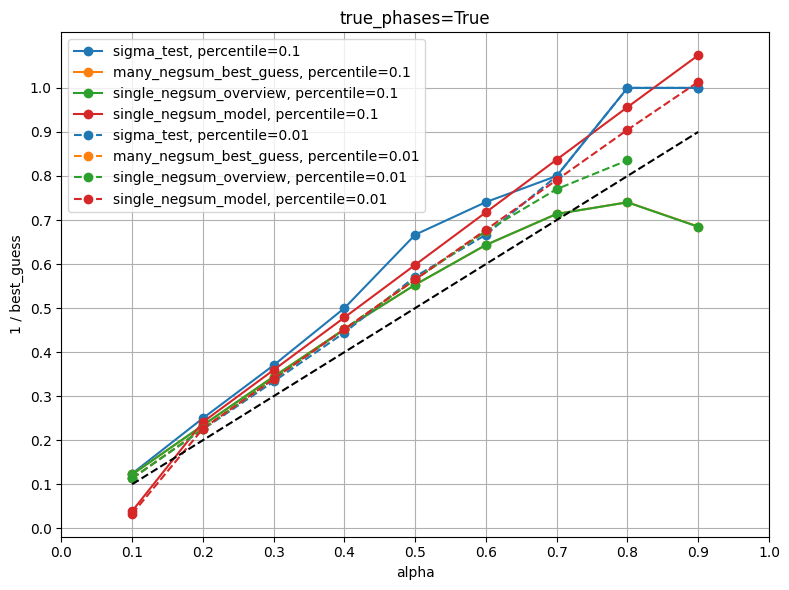

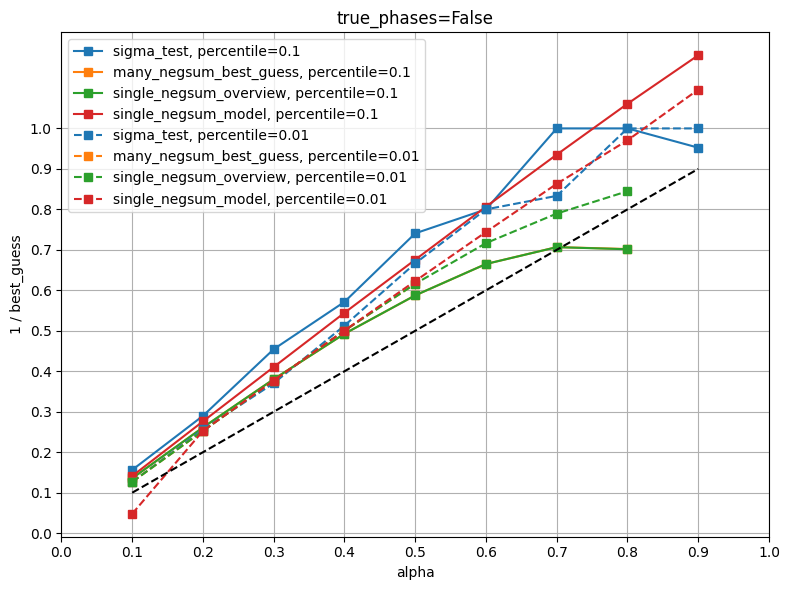

In [66]:
import itertools
from matplotlib.lines import Line2D

value_cols = [
    "sigma_test",
    "many_negsum_best_guess",
    "single_negsum_overview",
    "single_negsum_model",
]

conds = {
    # "alpha": 0.2,
    "phi_noise": 0,
    "offset": False,
}

vary_conds = [
    "true_phases", "percentile"
]

method_colors = {
    "sigma_test": "tab:blue",
    "many_negsum_best_guess": "tab:orange",
    "single_negsum_overview": "tab:green",
    "single_negsum_model": "tab:red",
}

plt.figure(figsize=(8, 10))
subset = df.copy()
for key, val in conds.items():
    subset = subset[subset[key] == val]
# Get all unique values for each vary_cond in the subset
vary_cond_values = [subset[vary_cond].unique() for vary_cond in vary_conds]
# Create cartesian product of all combinations
for combo in itertools.product(*vary_cond_values):
    mask = np.ones(len(subset), dtype=bool)
    label_parts = []
    for i, vary_cond in enumerate(vary_conds):
        mask &= (subset[vary_cond] == combo[i])
        label_parts.append(f"{vary_cond}={combo[i]}")
    subsub = subset[mask]
    if not subsub.empty:
        marker_map = {True: 'o', False: 's'}
        linestyle_map = {0.1: '-', 0.01: '--'}
        marker = marker_map[combo[0]]  # true_phases
        linestyle = linestyle_map[combo[1]]  # percentile
        for col in value_cols:
            y_col = f"{col}_best_guess"
            if y_col in subsub.columns:
                plt.plot(
                    subsub["alpha"],
                    1/ subsub[y_col],
                    marker=marker,
                    color=method_colors[col],
                    linestyle=linestyle,
                    label=f"{col}, {', '.join(label_parts)}"
                )

# Custom legend handles for methods (colors)
method_handles = [
    Line2D([0], [0], color=color, lw=2, label=method)
    for method, color in method_colors.items()
]

# Custom legend handles for markers (true_phases)
marker_handles = [
    Line2D([0], [0], color='k', marker=marker, linestyle='', label=f"true_phases={val}")
    for val, marker in marker_map.items()
]

# Custom legend handles for linestyles (percentile)
linestyle_handles = [
    Line2D([0], [0], color='k', linestyle=ls, lw=2, label=f"percentile={val}")
    for val, ls in linestyle_map.items()
]

plt.legend(handles=method_handles + marker_handles + linestyle_handles, loc="upper left")
plt.plot(subset["alpha"], subset["alpha"], 'k--', label="y=x")
# gridlines every 0.1
plt.xticks(np.arange(0, 1.1, 0.1))
plt.grid()

# vary_cond = ["percentile"]
for true_phase_val in [True, False]:
    plt.figure(figsize=(8, 6))
    for combo in itertools.product(*vary_cond_values):
        # Only plot for the current true_phases value
        if combo[0] != true_phase_val:
            continue
        mask = np.ones(len(subset), dtype=bool)
        label_parts = []
        for i, vary_cond in enumerate(vary_conds):
            mask &= (subset[vary_cond] == combo[i])
            if vary_cond == "true_phases":
                continue
            label_parts.append(f"{vary_cond}={combo[i]}")
        subsub = subset[mask]
        if not subsub.empty:
            marker_map = {True: 'o', False: 's'}
            linestyle_map = {0.1: '-', 0.01: '--'}
            marker = marker_map[combo[0]]  # true_phases
            linestyle = linestyle_map[combo[1]]  # percentile
            for col in value_cols:
                y_col = f"{col}_best_guess"
                if y_col in subsub.columns:
                    plt.plot(
                        subsub["alpha"],
                        1 / subsub[y_col],
                        marker=marker,
                        color=method_colors[col],
                        linestyle=linestyle,
                        label=f"{col}, {', '.join(label_parts)}"
                    )
    plt.title(f"true_phases={true_phase_val}")
    plt.legend(loc="upper left")
    plt.plot(subset["alpha"], subset["alpha"], 'k--', label="y=x")
    plt.xticks(np.arange(0, 1.1, 0.1))
    plt.yticks(np.arange(0, 1.1, 0.1))
    plt.xlabel("alpha")
    plt.ylabel("1 / best_guess")
    plt.grid()
    plt.tight_layout()



In [54]:
import gemmi

hkl = gemmi.Fractional(0,0,0).to_hkl
hkl

AttributeError: 'gemmi.Fractional' object has no attribute 'to_hkl'

In [ ]:
plt.figure(figsize=(8,6))
# print all columns except for these
# remove "unnamed columns"
df = df[[col for col in df.columns if "Unnamed" not in col]]
df = df.reset_index(drop=True)
# df[[col for col in df.columns if col not in value_cols]]
def get_last_best_guess_from_col(df, col_name):

    def get_last_best_guess(val):
        if isinstance(val, dict) and 'best_guess' in val:
            return val['best_guess'][-1] if isinstance(val['best_guess'], (list, np.ndarray)) else val['best_guess']
        return np.nan
    return df[col_name].apply(get_last_best_guess)
col = "sigma_test"
for col in value_cols:
    df[col + "_last"] = get_last_best_guess_from_col(df, col)

df.loc[0,"sigma_test"]
df 


KeyError: 'sigma_test'

<Figure size 800x600 with 0 Axes>

In [ ]:
print(df.loc[0,"sigma_test"])

#convert string representation of dict to actual dict
string_dict = df.loc[0,"sigma_test"]
if isinstance(string_dict, str):
    import ast
    string_dict = ast
print(df.loc[0,"sigma_test"]])
print(df.loc[0,"sigma_test"]["thresholds"])
print(df.loc[0,"sigma_test"]["best_guess"])


{'thresholds': array([17.32937813, 58.91988564]), 'thresholds_rmsd': array([17.32937813, 58.91988564]), 'best_guess': [1.0, 1.0], 'uncertainty': [0.0, 0.0]}
h


TypeError: string indices must be integers, not 'str'

In [6]:
df[[col for col in df.columns if col not in value_cols]]


,f_noise,phi_noise,alpha,offset,true_phases,percentile,sigma,sigma_test_last,many_negsum_best_guess_last,single_negsum_overview_last,single_negsum_model_last
0,0.0,0.0,0.2,True,True,0.0001,-69.317516,NaN,NaN,NaN,NaN
1,0.0,0.0,0.2,True,True,0.0001,-69.317516,NaN,NaN,NaN,NaN
2,0.0,0.0,0.2,True,True,0.0100,-32.185765,NaN,NaN,NaN,NaN
3,0.0,0.0,0.2,False,True,0.0001,-69.317516,NaN,NaN,NaN,NaN
4,0.0,0.0,0.2,False,True,0.0100,-32.185765,NaN,NaN,NaN,NaN
5,0.0,0.0,0.2,True,False,0.0001,-50.967581,NaN,NaN,NaN,NaN
6,0.0,0.0,0.2,True,False,0.0100,-24.244950,NaN,NaN,NaN,NaN
7,0.0,0.0,0.2,False,False,0.0001,-50.967585,NaN,NaN,NaN,NaN
8,0.0,0.0,0.2,False,False,0.0100,-24.244950,NaN,NaN,NaN,NaN
9,0.0,0.0,0.5,True,True,0.0001,-69.317533,NaN,NaN,NaN,NaN


In [ ]:
# group by f_noise, phi_noise, percentile, offset, alpha 
grouped = df.groupby(["f_noise", "phi_noise", "percentile", "offset", "alpha"])
